# Netflix Success Prediction — EDA & Hypothesis Testing

**Research questions:**
- Which genres tend to have higher IMDB ratings?
- Do TV shows perform better than movies?
- Does release year affect content success?
- How does country of origin influence ratings?
- Is popularity (vote count) correlated with perceived quality (IMDB rating)?

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set(style="whitegrid")

## 2. Data Collection & Loading

In [2]:
#data loading
netflix = pd.read_csv('../data/raw/netflix_titles.csv')
imdb = pd.read_csv('../data/raw/Netflix TV Shows and Movies.csv')

print(netflix.shape)
print(netflix.columns)
print(imdb.shape)
print(imdb.columns)

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
(5283, 11)
Index(['index', 'id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'imdb_id', 'imdb_score', 'imdb_votes'],
      dtype='str')


### Dataset Previews

In [3]:
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [4]:
imdb.head(2)

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0


## 3. Data Merging

Both datasets are merged on the 'title' column (normalized to lowercase and stripped of whitespace) using an **inner join**, retaining only titles that appear in both datasets.

In [5]:
# merge
netflix['title'] = netflix['title'].str.lower().str.strip()
imdb['title'] = imdb['title'].str.lower().str.strip()

df = pd.merge(netflix, imdb, on='title', how='inner')

print("Merged shape:", df.shape)
df.head(3)

Merged shape: (3960, 22)


,show_id,type_x,title,director,cast,country,date_added,release_year_x,rating,duration,...,index,id,type_y,description_y,release_year_y,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,s1,Movie,dick johnson is dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,3241,tm845484,MOVIE,"With this inventive portrait, director Kirsten...",2020,PG-13,89,tt11394180,7.4,6390.0
1,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,4811,ts304058,SHOW,"Mehdi, a qualified robber, and Liana, an appre...",2021,TV-MA,46,tt13278100,7.0,2460.0
2,s4,TV Show,jailbirds new orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,5190,ts308053,SHOW,"Feuds, flirtations and toilet talk go down amo...",2021,TV-MA,41,tt15320436,6.6,205.0


### Inspecting Merged Columns

In [6]:
df.columns

Index(['show_id', 'type_x', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year_x', 'rating', 'duration', 'listed_in',
       'description_x', 'index', 'id', 'type_y', 'description_y',
       'release_year_y', 'age_certification', 'runtime', 'imdb_id',
       'imdb_score', 'imdb_votes'],
      dtype='str')

## 4. Data Cleaning & Preprocessing

- Convert `imdb_score` and `imdb_votes` to numeric, dropping rows where either is missing.
- Fill missing 'country' values with `'Unknown'`.

In [7]:
#numeric conversion and cleaning missing values
df['imdb_score'] = pd.to_numeric(df['imdb_score'], errors='coerce')
df['imdb_votes'] = pd.to_numeric(df['imdb_votes'], errors='coerce')
df['release_year'] = pd.to_numeric(df['release_year_x'], errors='coerce')

df = df.dropna(subset=['imdb_score', 'imdb_votes'])
df['country'] = df['country'].fillna('Unknown')

print(df.shape)
df.isnull().sum()

(3955, 23)


show_id                 0
type_x                  0
title                   0
director             1429
cast                  362
country                 0
date_added              0
release_year_x          0
rating                  0
duration                1
listed_in               0
description_x           0
index                   0
id                      0
type_y                  0
description_y           3
release_year_y          0
age_certification    1718
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
release_year            0
dtype: int64

### Column Renaming & Duration Extraction

In [8]:
#rename and extract duration
df = df.rename(columns={
    'type_x': 'type',
    'description_x': 'description',
    'rating': 'content_rating'
})

df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

## 5. Feature Engineering — Composite Score

A **composite success score** is computed as a weighted combination of two normalized components:

| Component | Weight | Rationale |
|---|---|---|
| IMDB score (normalized) | 60% | Perceived quality |
| Log-transformed vote count (normalized) | 40% | Popularity / reach |

Both components are scaled to [0, 1] via Min-Max normalization before combining. The log transform on vote count reduces the effect of extreme outliers.

In [9]:
#calculate composite score
scaler = MinMaxScaler()

df['imdb_score_norm'] = scaler.fit_transform(df[['imdb_score']])
df['imdb_votes_log'] = np.log1p(df['imdb_votes'])
df['imdb_votes_norm'] = scaler.fit_transform(df[['imdb_votes_log']])
df['composite_score'] = 0.6 * df['imdb_score_norm'] + 0.4 * df['imdb_votes_norm']

df[['title', 'imdb_score', 'imdb_votes', 'composite_score']].head(10)

,title,imdb_score,imdb_votes,composite_score
0,dick johnson is dead,7.4,6390.0,0.654152
1,ganglands,7.0,2460.0,0.594799
2,jailbirds new orleans,6.6,205.0,0.487913
3,kota factory,9.3,66985.0,0.868073
4,midnight mass,7.7,102321.0,0.762749
5,my little pony: a new generation,6.8,3468.0,0.590676
6,sankofa,7.0,678.0,0.554692
7,the great british baking show,8.6,9564.0,0.755599
8,the starling,6.3,11733.0,0.591594
9,"vendetta: truth, lies and the mafia",6.7,232.0,0.499157


### Final Dataset Structure

In [10]:
# select and reorder relevant columns
df = df[['title', 'type', 'country', 'release_year', 'duration', 'duration_int', 
         'listed_in', 'content_rating', 'description', 'imdb_score', 'imdb_votes', 
         'imdb_score_norm', 'imdb_votes_log', 'imdb_votes_norm', 'composite_score']]

print(df.shape)
df.head()

(3955, 15)


,title,type,country,release_year,duration,duration_int,listed_in,content_rating,description,imdb_score,imdb_votes,imdb_score_norm,imdb_votes_log,imdb_votes_norm,composite_score
0,dick johnson is dead,Movie,United States,2020,90 min,90.0,Documentaries,PG-13,"As her father nears the end of his life, filmm...",7.4,6390.0,0.728395,8.762646,0.542787,0.654152
1,ganglands,TV Show,Unknown,2021,1 Season,1.0,"Crime TV Shows, International TV Shows, TV Act...",TV-MA,To protect his family from a powerful drug lor...,7.0,2460.0,0.679012,7.808323,0.468478,0.594799
2,jailbirds new orleans,TV Show,Unknown,2021,1 Season,1.0,"Docuseries, Reality TV",TV-MA,"Feuds, flirtations and toilet talk go down amo...",6.6,205.0,0.629630,5.327876,0.275339,0.487913
3,kota factory,TV Show,India,2021,2 Seasons,2.0,"International TV Shows, Romantic TV Shows, TV ...",TV-MA,In a city of coaching centers known to train I...,9.3,66985.0,0.962963,11.112239,0.725737,0.868073
4,midnight mass,TV Show,Unknown,2021,1 Season,1.0,"TV Dramas, TV Horror, TV Mysteries",TV-MA,The arrival of a charismatic young priest brin...,7.7,102321.0,0.765432,11.535880,0.758724,0.762749


### Missing Value Summary

In [11]:
print(df.shape)
df.isnull().sum()

(3955, 15)


title              0
type               0
country            0
release_year       0
duration           1
duration_int       1
listed_in          0
content_rating     0
description        0
imdb_score         0
imdb_votes         0
imdb_score_norm    0
imdb_votes_log     0
imdb_votes_norm    0
composite_score    0
dtype: int64

## 6. Exploratory Data Analysis (EDA)

### 6.1 Score Distributions

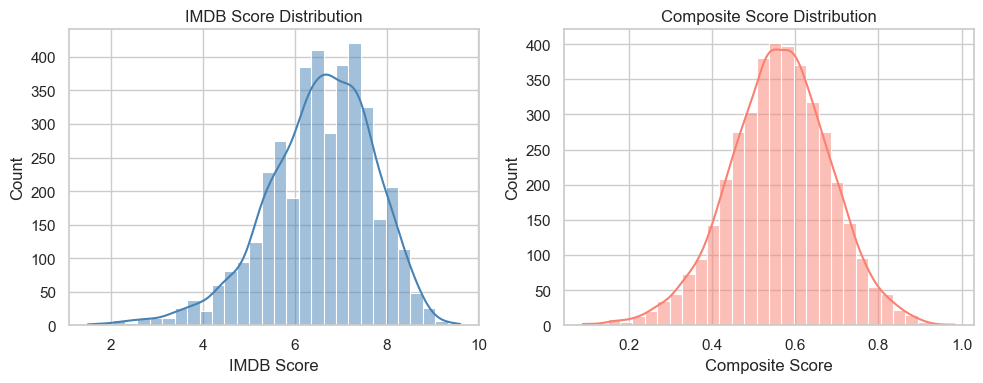

In [12]:
#imdb score distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['imdb_score'], bins=30, kde=True, color='steelblue')
plt.title('IMDB Score Distribution')
plt.xlabel('IMDB Score')

plt.subplot(1, 2, 2)
sns.histplot(df['composite_score'], bins=30, kde=True, color='salmon')
plt.title('Composite Score Distribution')
plt.xlabel('Composite Score')

plt.tight_layout()
plt.show()

### 6.2 Movie vs TV Show Comparison

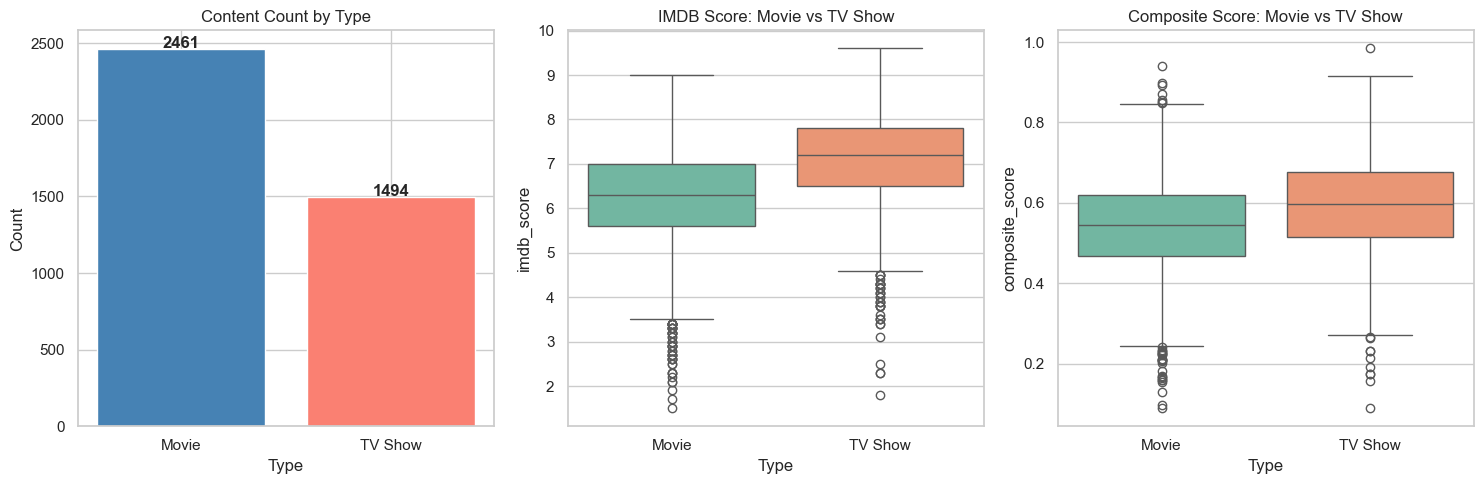

In [13]:
# content type count and score comparison: Movie vs TV Show
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Count by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Content Count by Type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# IMDB score by type
sns.boxplot(data=df, x='type', y='imdb_score', hue='type', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('IMDB Score: Movie vs TV Show')
axes[1].set_xlabel('Type')

# Composite score by type
sns.boxplot(data=df, x='type', y='composite_score', hue='type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Composite Score: Movie vs TV Show')
axes[2].set_xlabel('Type')

plt.tight_layout()
plt.show()

### 6.3 Genre Analysis

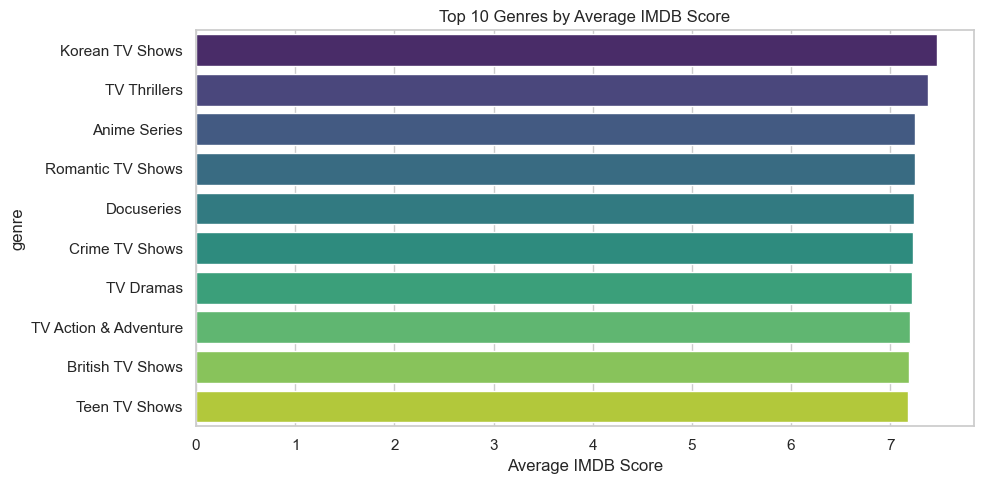

In [14]:
# top 10 genres by average IMDB score
genre_df = df.copy()
genre_df['genre'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('genre')

top_genres = genre_df.groupby('genre')['imdb_score'].agg(['mean', 'count'])
top_genres = top_genres[top_genres['count'] >= 30].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres['mean'], y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title('Top 10 Genres by Average IMDB Score')
plt.xlabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.4 Release Year Trends

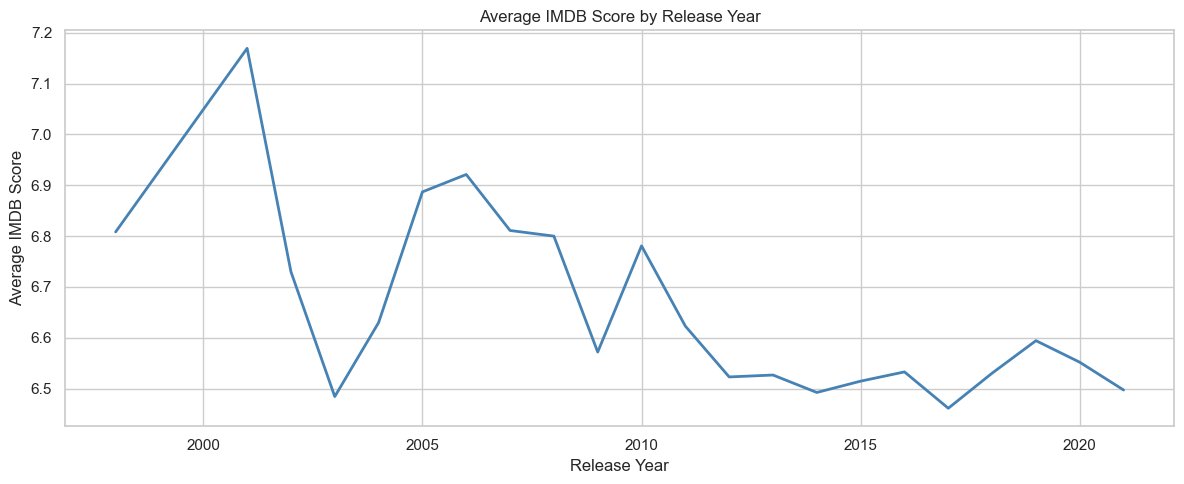

In [15]:
# average IMDB score by release year
yearly = df.groupby('release_year')['imdb_score'].agg(['mean', 'count']).reset_index()
yearly = yearly[yearly['count'] >= 10]  # only years with at least 10 titles

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='release_year', y='mean', color='steelblue', linewidth=2)
plt.title('Average IMDB Score by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.5 Country Analysis

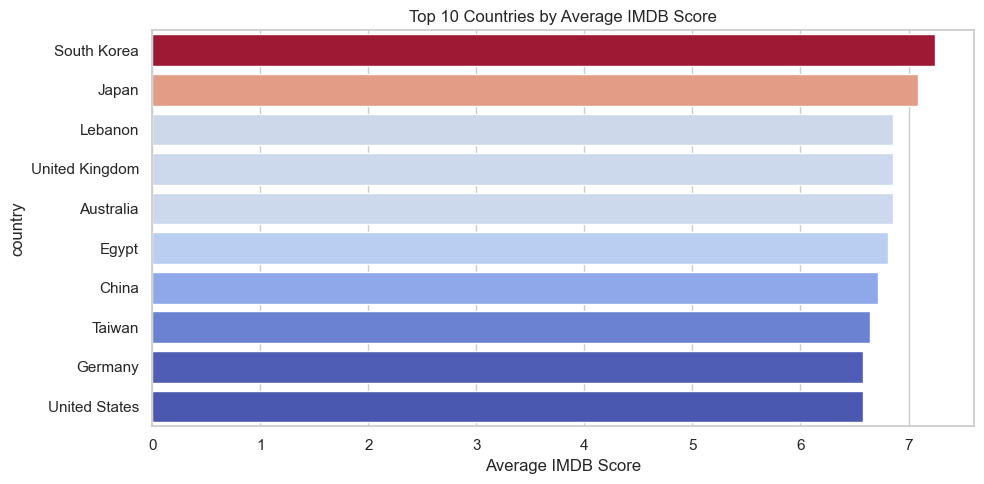

In [16]:
# top 10 countries by average IMDB score (excluding Unknown)
country_df = df[df['country'] != 'Unknown'].copy()
country_df['country'] = country_df['country'].str.split(', ')
country_df = country_df.explode('country')
country_df = country_df[country_df['country'] != 'Unknown']

top_countries = country_df.groupby('country')['imdb_score'].agg(['mean', 'count']).reset_index()
top_countries = top_countries[top_countries['count'] >= 20].sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x='mean', y='country', hue='mean', palette='coolwarm', legend=False)
plt.title('Top 10 Countries by Average IMDB Score')
plt.xlabel('Average IMDB Score')
plt.tight_layout()
plt.show()

### 6.6 Duration vs IMDB Score

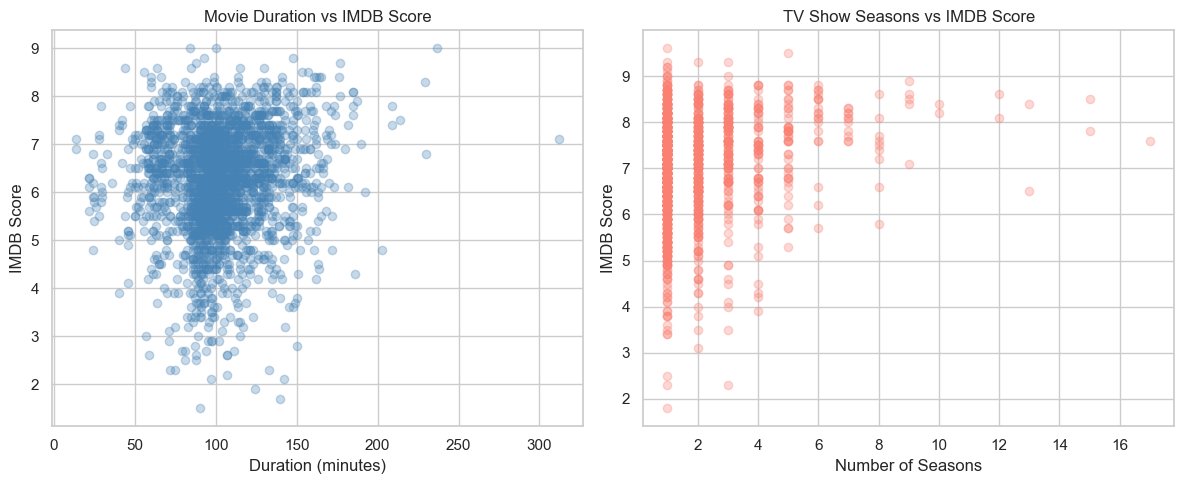

In [17]:
#duration vs score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Movies — duration in minutes
movies = df[df['type'] == 'Movie']
axes[0].scatter(movies['duration_int'], movies['imdb_score'], alpha=0.3, color='steelblue')
axes[0].set_title('Movie Duration vs IMDB Score')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('IMDB Score')

# TV Shows — number of seasons
shows = df[df['type'] == 'TV Show']
axes[1].scatter(shows['duration_int'], shows['imdb_score'], alpha=0.3, color='salmon')
axes[1].set_title('TV Show Seasons vs IMDB Score')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('IMDB Score')

plt.tight_layout()
plt.show()

### 6.7 Correlation Heatmap

Pairwise Pearson correlations between the key numeric variables: IMDB score, vote count, release year, duration, and composite score.

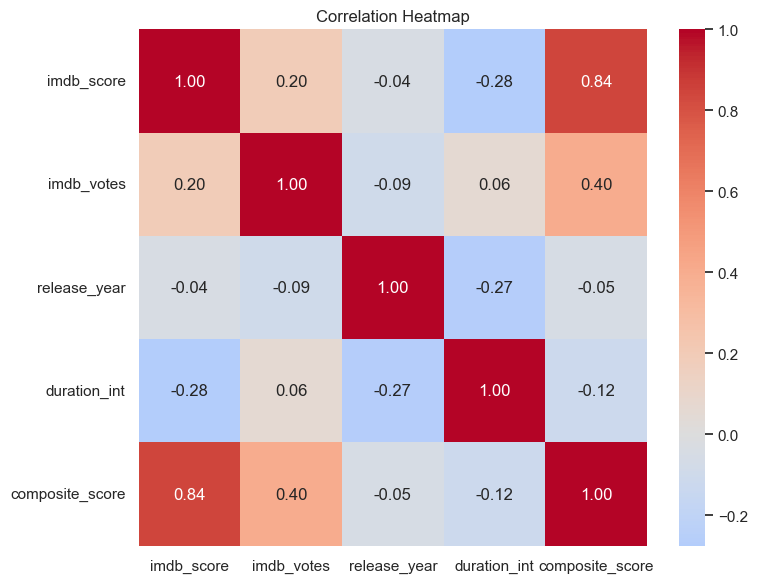

In [18]:
#correlation heatmap
corr_cols = ['imdb_score', 'imdb_votes', 'release_year', 'duration_int', 'composite_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Hypothesis Testing

Statistical tests to formally evaluate the research questions. Significance level: **α = 0.05**.

| # | Hypothesis | Test |
|---|---|---|
| 7.1 | TV shows and movies differ in mean IMDB score | Independent two-sample t-test |
| 7.2 | Mean IMDB score differs across genres | One-way ANOVA |
| 7.3 | Release year is correlated with IMDB score | Pearson & Spearman correlation |
| 7.4 | Vote count (popularity) is correlated with IMDB score (quality) | Pearson & Spearman correlation |

---

### 7.1 Two-Sample T-test: Movies vs TV Shows

**H₀:** Movies and TV shows have the same mean IMDB score.  
**H₁:** The mean IMDB scores differ between movies and TV shows.

In [19]:
#hypothesis testing:
from scipy import stats

movies_scores = df[df['type'] == 'Movie']['imdb_score']
shows_scores = df[df['type'] == 'TV Show']['imdb_score']

t_stat, p_value = stats.ttest_ind(movies_scores, shows_scores)

print(f"Movie mean:   {movies_scores.mean():.3f}")
print(f"TV Show mean: {shows_scores.mean():.3f}")
print(f"T-statistic:  {t_stat:.3f}")
print(f"P-value:      {p_value:.6f}")

if p_value < 0.05:
    print("\nSince p < 0.05, the difference is statistically significant")
else:
    print("\nSince p >= 0.05, the difference is not statistically significant")

Movie mean:   6.251
TV Show mean: 7.051
T-statistic:  -22.306
P-value:      0.000000

Since p < 0.05, the difference is statistically significant


### 7.2 One-Way ANOVA: Differences Across Genres

**H₀:** All genres share the same mean IMDB score.  
**H₁:** At least one genre differs significantly in mean IMDB score.

Genres with fewer than 30 titles are excluded to ensure reliable group estimates.

In [20]:
# ANOVA test for genres
from scipy.stats import f_oneway

genre_df = df.copy()
genre_df['genre'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('genre')

# genres with at least 30 entries
valid_genres = genre_df.groupby('genre').filter(lambda x: len(x) >= 30)
genre_groups = [group['imdb_score'].values for _, group in valid_genres.groupby('genre')]

f_stat, p_value = f_oneway(*genre_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Differences across genres are SIGNIFICANT (p < 0.05)")
else:
    print("\nResult: Differences across genres are NOT SIGNIFICANT (p >= 0.05)")

F-statistic: 59.929
P-value:     0.000000

Result: Differences across genres are SIGNIFICANT (p < 0.05)


### 7.3 Correlation: Release Year vs IMDB Score

**H₀:** There is no correlation between release year and IMDB score (ρ = 0).  
**H₁:** Release year and IMDB score are significantly correlated.

Both Pearson (linear) and Spearman (rank-based, robust to non-linearity) correlations are reported.

In [21]:
#release year and IMDB score correlation
from scipy.stats import pearsonr, spearmanr

clean = df[['release_year', 'imdb_score']].dropna()

pearson_r, pearson_p = pearsonr(clean['release_year'], clean['imdb_score'])
spearman_r, spearman_p = spearmanr(clean['release_year'], clean['imdb_score'])

print(f"Pearson  r: {pearson_r:.3f}, p-value: {pearson_p:.6f}")
print(f"Spearman r: {spearman_r:.3f}, p-value: {spearman_p:.6f}")

if pearson_p < 0.05:
    print("\nResult: Correlation between release year and IMDB score is SIGNIFICANT (p < 0.05)")
else:
    print("\nResult: Correlation is NOT SIGNIFICANT (p >= 0.05)")

Pearson  r: -0.039, p-value: 0.014476
Spearman r: -0.018, p-value: 0.254869

Result: Correlation between release year and IMDB score is SIGNIFICANT (p < 0.05)


### 7.4 Correlation: Vote Count vs IMDB Score

**H₀:** There is no correlation between vote count (popularity) and IMDB score (quality).  
**H₁:** Vote count and IMDB score are significantly correlated.

This directly tests the research question: *Is popularity correlated with perceived quality?*

Pearson  r: 0.195, p-value: 0.000000
Spearman r: 0.239, p-value: 0.000000

Result: Correlation between vote count and IMDB score is SIGNIFICANT (p < 0.05)


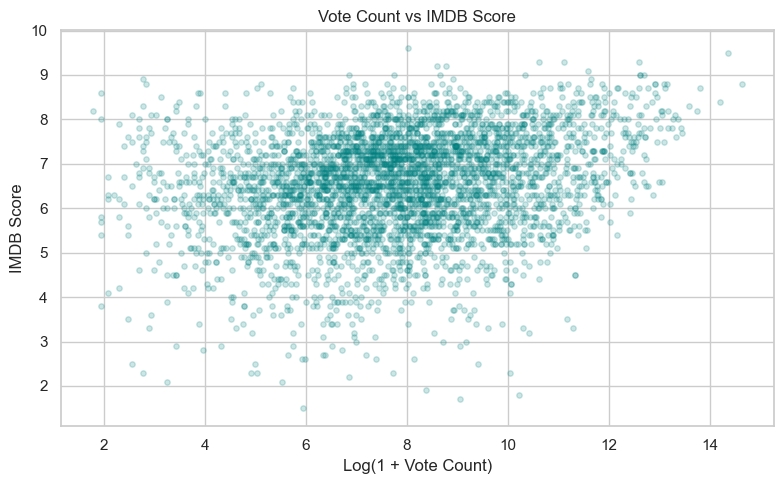

In [22]:
from scipy.stats import pearsonr, spearmanr

clean_votes = df[['imdb_votes', 'imdb_score']].dropna()

pearson_r, pearson_p = pearsonr(clean_votes['imdb_votes'], clean_votes['imdb_score'])
spearman_r, spearman_p = spearmanr(clean_votes['imdb_votes'], clean_votes['imdb_score'])

print(f"Pearson  r: {pearson_r:.3f}, p-value: {pearson_p:.6f}")
print(f"Spearman r: {spearman_r:.3f}, p-value: {spearman_p:.6f}")

if pearson_p < 0.05:
    print("\nResult: Correlation between vote count and IMDB score is SIGNIFICANT (p < 0.05)")
else:
    print("\nResult: Correlation is NOT SIGNIFICANT (p >= 0.05)")

# scatter plot: log vote count vs IMDB score
plt.figure(figsize=(8, 5))
plt.scatter(np.log1p(df['imdb_votes']), df['imdb_score'], alpha=0.2, color='teal', s=15)
plt.xlabel('Log(1 + Vote Count)')
plt.ylabel('IMDB Score')
plt.title('Vote Count vs IMDB Score')
plt.tight_layout()
plt.show()